# Adjacent Mouse Brain Slice Stitching

In [2]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff as sd
from SpaDiff.utils import adjust_louvain_resolution, set_seed

In [ ]:
SEED = 42
SLICE_ORDER = ["Anterior", "Posterior"]
REFERENCE_BATCH = "Anterior"
N_CLUSTERS = 30
N_COMPONENTS = 50
N_NEIGHBORS = 10
TOPOLOGY_MODE = "global_knn"
TRAINING_EPOCHS = 300

MAX_ORDER = 2
SIMPLEX_ORDERS = (
    (0,) if MAX_ORDER == 0
    else tuple(range(1, MAX_ORDER + 1))
)
DSM_WEIGHTING = "variance"
PRIOR_KL_LOSS_WEIGHT = 0.0  

DATA_ROOT = Path("E:/gxy_2/final/0_data/case2/")
print("DATA_ROOT =", DATA_ROOT)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)

DATA_ROOT = E:\gxy_2\final\0_data\case2
device = cuda:0


## Data loading 

In [4]:
adata = sc.read_h5ad(DATA_ROOT /"MouseBrain.h5ad")
adata.var_names_make_unique()

## Preprocessing

In [6]:
adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts",n_top_genes=3000, batch_key="batch_name")
adata = adata[:, adata.var["highly_variable"]].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, n_comps=N_COMPONENTS)
features = torch.as_tensor(np.asarray(adata.obsm["X_pca"], dtype=np.float32), device=device)

## Spatial topology

In [7]:
topology = sd.build_spatial_topology(
    adata,
    mode=TOPOLOGY_MODE,
    n_neighbors=N_NEIGHBORS,
    max_order=MAX_ORDER,
    device=device,
)
operators = topology.operators

Simplicial complex statistics:
  order 0 (vertices): 6,049
  order 1 (edges): 29,353
  order 2 (triangles): 38,893


## SpaDiff training

In [ ]:
config = sd.SpaDiffConfig(
    data_dim=features.shape[1],
    condition_input_dim=features.shape[1],
    score_depth=4,
    dropout=0.2,
    topology_projection_dropout=0.1,
    topology_output_normalization="feature",
    simplex_orders=SIMPLEX_ORDERS,
    propagation_steps=5,
    propagation_alpha=0.4,
    num_batches=len(SLICE_ORDER),
    dsm_weighting=DSM_WEIGHTING,
    prior_kl_weight=PRIOR_KL_LOSS_WEIGHT,
    batch_balanced_loss=True,
)
model = sd.SpaDiff(config).to(device)
adata = model.fit_transform(
    adata,
    features,
    operators,
    condition_features=features,
    batch_key="batch_name",
    batch_order=SLICE_ORDER,
    reference_batch=REFERENCE_BATCH,
    epochs=TRAINING_EPOCHS,
    progress=True,
    ode_steps=300,
)

Training SpaDiff: 100%|██████████| 300/300 [00:10<00:00, 29.88epoch/s]


## Spatial domains


In [14]:
sc.pp.neighbors(adata, use_rep='X_spadiff', n_neighbors=15, random_state=SEED)
sc.tl.louvain( adata, key_added="louvain", resolution=1.6, random_state=SEED)

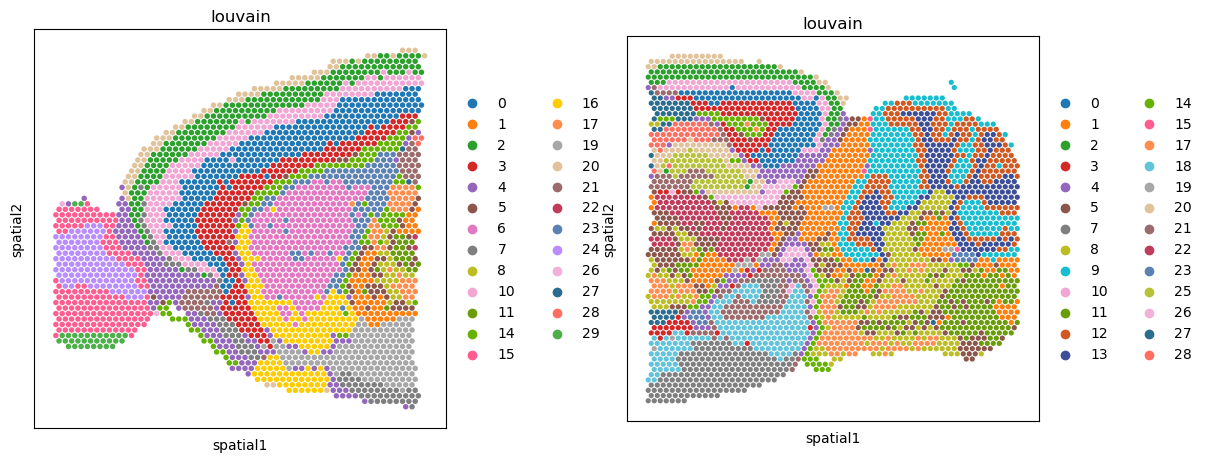

In [24]:
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#f2a6d4", "#6a9c0a", "#d1581e", "#3b4e97", "#66b200",
    "#ff5c8f", "#ffcc00", "#ff8d4d", "#62c4da", "#a7a7a7",
    "#e1c39b", "#9c6c6c", "#c13b5b", "#5c82b3", "#ba8dff",
    "#b8c239", "#f2b1d9", "#2c6d8f", "#ff6f61", "#4daf4a",
]

plot_color = {str(i): c for i, c in enumerate(colors)}
fig, axes = plt.subplots(1, len(SLICE_ORDER), figsize=(12, 5))
for axis, sample in zip(np.atleast_1d(axes), SLICE_ORDER):
    subset = adata[adata.obs["dataset_batch"] == sample].copy()
    sc.pl.spatial(
        subset, img_key=None, color="louvain", ax=axis, show=False,
        spot_size=120, palette=plot_color, 
        # frameon=False, title=sample,legend_loc=None,
    )
plt.tight_layout()
plt.show()

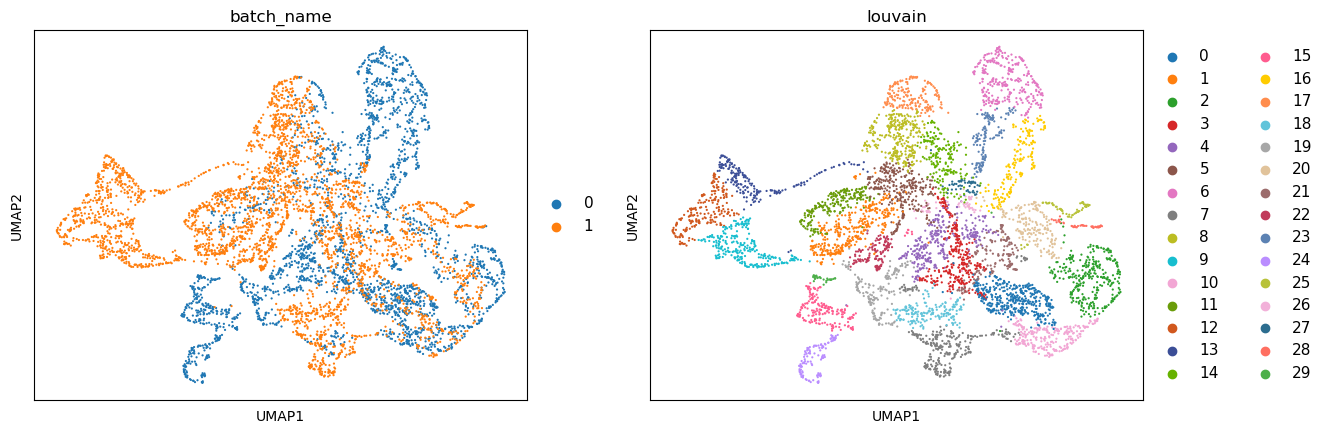

In [26]:
sc.tl.umap(adata, random_state=SEED)
sc.pl.umap(
    adata, color=["batch_name", "louvain"], size=10,
    legend_fontsize=11, legend_fontoutline=2,
)